# Desorfanización global: r*G y partición directa/indirecta

Ranking **global** (sobre todas las proteínas de la red, no sólo las de la
especie): curva de recuperación ρ(rG), su derivada λ(rG) y el corte **r\*G**
donde λ̃ cae al ruido de fondo (Fig 3A del paper 2016). Distribución de `rSS` y
partición de los aciertos en **inferencia directa** (el blanco verdadero está
entre las semillas) e **indirecta** (sólo se llega por la capa de afiliaciones).

No vuelve a correr el modelo: post-procesa lo que dejó el notebook `01`, que ya
guarda `rG`, `rSS` y la clase de inferencia por droga.

Fuente: `reproducir_v6/desorfanizacion_global/` + `inferencia_directa_indirecta/`.
Salidas: `03_ranking_global.csv`, `03_curva_recuperacion.csv`, `03_rg_estrella.csv`,
`03_clases_inferencia.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

V4 = "/home/ggiordano/TDR/TDR_2026_v4"
sys.path.insert(0, f"{V4}/comun")
sys.path.insert(0, f"{V4}/huerfanas")
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "03"                             # numero de este notebook: prefija todo lo que genere
n_core  = 20

plt = tdr.estilo()
SALIDAS

PosixPath('/home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out')

## Datos

In [2]:
HUERFANAS = tdr.out("huerfanas")
res = fh.cargar_resultados(HUERFANAS, "01", patron="*_pseudohuerfanas")
k1  = pd.read_csv(HUERFANAS / "01_k1_drugs.csv")
res = res.merge(k1[["drug_id", "sp_id", "grupo"]].rename(columns={"sp_id": "especie"}),
                on=["drug_id", "especie"], how="left")
res.shape, tdr.leer_meta(HUERFANAS, "01")["fecha"]

((7782, 14), '2026-09-07 12:52')

## Acondicionamiento

1312 de 7782 drogas con ranking global (16.9%); el resto tiene semilla nula
{'indirecta': 0.905, 'directa': 0.095}
  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/03_f01_distribucion_rg.pdf


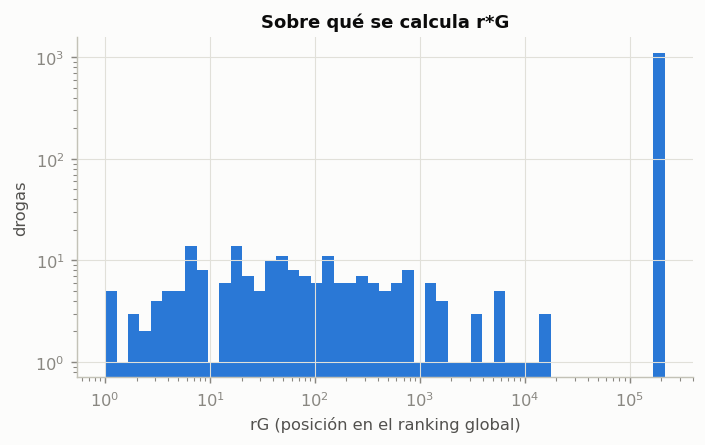

In [3]:
con_rg = res[res["rG"].notna()].copy()
print(f"{len(con_rg)} de {len(res)} drogas con ranking global "
      f"({len(con_rg)/len(res):.1%}); el resto tiene semilla nula")
print(con_rg["clase"].value_counts(normalize=True).round(3).to_dict())

fig, ax = plt.subplots(figsize=(5.5, 3.5), tight_layout=True)
ax.hist(con_rg["rG"], bins=np.logspace(0, np.log10(con_rg["rG"].max()), 50), color=tdr.S1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("rG (posición en el ranking global)")
ax.set_ylabel("drogas")
ax.set_title("Sobre qué se calcula r*G")
tdr.guardar(fig, f"{NB}_f01_distribucion_rg", FIGURAS)

## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
curva = fh.curva_recuperacion(con_rg["rG"], l_max=1000)
curva, rg_star = fh.r_g_estrella(curva)

rss = (con_rg.groupby(con_rg["rSS"].astype(int)).size().reset_index(name="n")
       .rename(columns={"rSS": "posicion"}))
rss["frac_acumulada"] = rss["n"].cumsum() / rss["n"].sum()

clases = con_rg.groupby(["clase", "especie"]).agg(
    n=("drug_id", "size"), rG_mediana=("rG", "median"), rSS_mediana=("rSS", "median")
).reset_index()

con_rg.to_csv(SALIDAS / f"{NB}_ranking_global.csv", index=False)
curva.to_csv(SALIDAS / f"{NB}_curva_recuperacion.csv", index=False)
rg_star.to_csv(SALIDAS / f"{NB}_rg_estrella.csv", index=False)
rss.to_csv(SALIDAS / f"{NB}_rss_distribucion.csv", index=False)
clases.to_csv(SALIDAS / f"{NB}_clases_inferencia.csv", index=False)
fh.escribir_meta(SALIDAS, NB, notebook="03_desorfanizacion_global.ipynb",
                 params={"l_max": 1000, "k_sigma": 3.0}, fuente_nb="01",
                 r_g_estrella=float(rg_star["r_g_estrella"].iloc[0]))

  meta -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/03_meta.json


{'notebook': '03_desorfanizacion_global.ipynb',
 'nb': '03',
 'fecha': '2026-09-07 13:44',
 'params': {'l_max': 1000, 'k_sigma': 3.0},
 'n_core': None,
 'tablas_db': {'00_specie_target.csv': '2026-06-05',
  '00_specie_target_full.csv': '2026-06-05',
  '01_clusters_fingerprint.csv': '2026-05-13',
  '01_deleted_compounds.csv': '2026-05-13',
  '01_edges_clusters_fingerprint.csv': '2026-05-13',
  '02_clusters_subestructure.csv': '2026-05-13',
  '02_edges_clusters_subestructure.csv': '2026-05-13',
  '03_bioactivities_organism_compound.csv': '2026-06-04',
  '03_bioactivities_target_compound.csv': '2026-08-07',
  '04a_interpro.csv': '2026-06-10',
  '04b_orthomcl.csv': '2026-08-25'},
 'python': '3.12.2',
 'pandas': '2.2.3',
 'fuente_nb': '01',
 'r_g_estrella': 54.0}

# Resultados

In [5]:
curva   = pd.read_csv(SALIDAS / f"{NB}_curva_recuperacion.csv")
rg_star = pd.read_csv(SALIDAS / f"{NB}_rg_estrella.csv")
rss     = pd.read_csv(SALIDAS / f"{NB}_rss_distribucion.csv")
clases  = pd.read_csv(SALIDAS / f"{NB}_clases_inferencia.csv")
rg_star

,lambda_inf,sigma,umbral,r_g_estrella,k_sigma,desde
0,0.085471,0.126291,0.464344,54.0,3.0,50


  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/03_f02_recuperacion.pdf


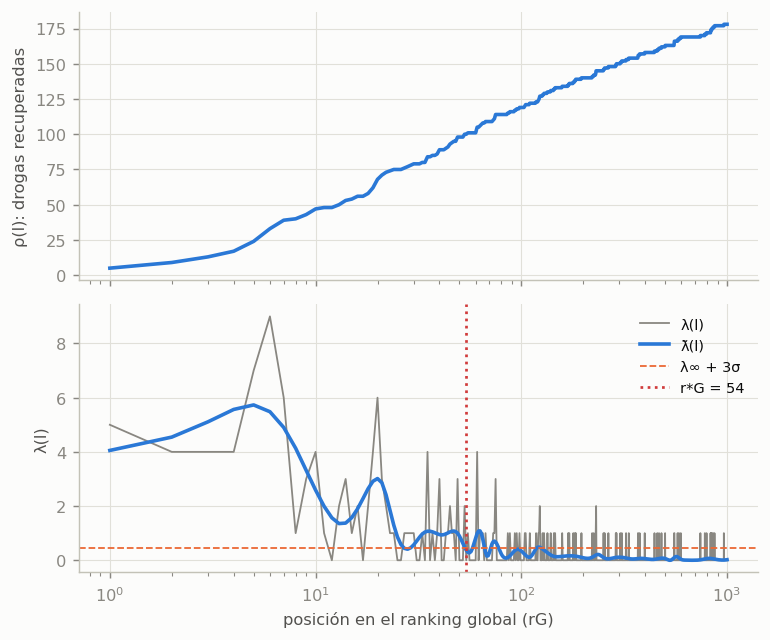

In [6]:
fig = fh.fig_recuperacion(curva, rg_star, plt)
tdr.guardar(fig, f"{NB}_f02_recuperacion", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/03_f03_rss.pdf


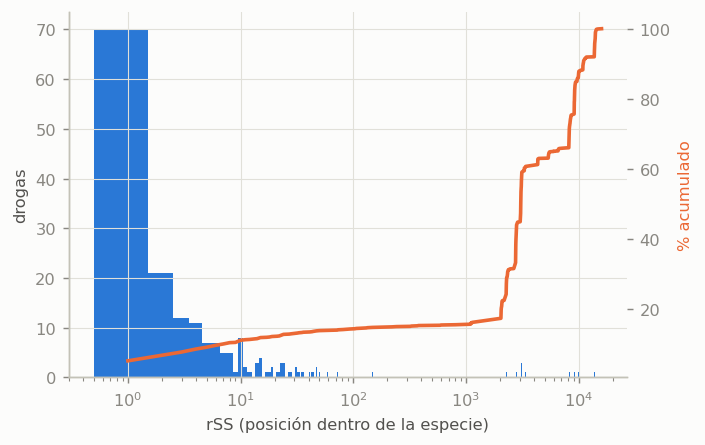

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 3.5), tight_layout=True)
ax.bar(rss["posicion"], rss["n"], color=tdr.S1, width=1.0)
ax2 = ax.twinx()
ax2.plot(rss["posicion"], 100 * rss["frac_acumulada"], color=tdr.S2)
ax2.set_ylabel("% acumulado", color=tdr.S2)
ax2.grid(False)
ax.set_xscale("log")
ax.set_xlabel("rSS (posición dentro de la especie)")
ax.set_ylabel("drogas")
tdr.guardar(fig, f"{NB}_f03_rss", FIGURAS)

  figura -> /home/ggiordano/TDR/TDR_2026_v4/gon4/huerfanas_out/figuras/03_f04_directa_indirecta.pdf


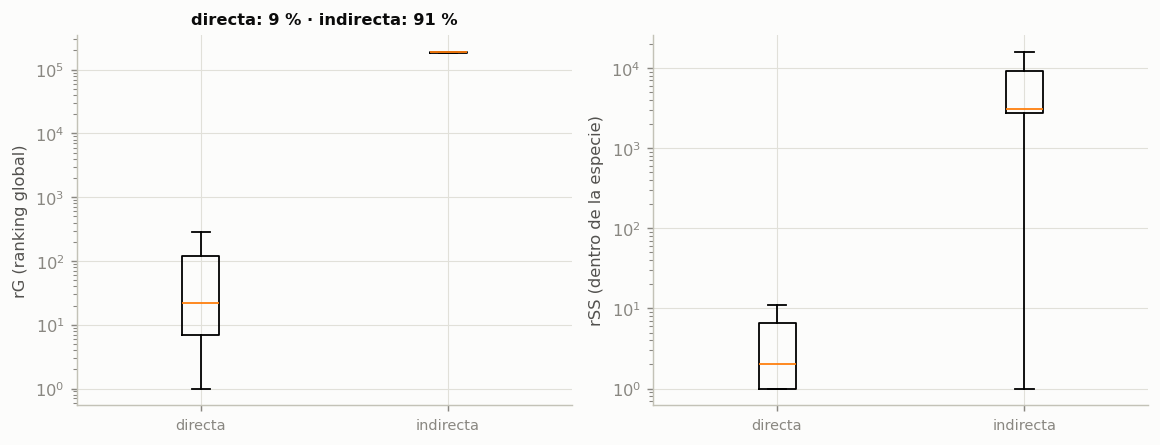

In [8]:
# Partición directa / indirecta; el paper 2016 reporta 68 % / 32 %
fig = fh.fig_inferencia(con_rg, plt)
tdr.guardar(fig, f"{NB}_f04_directa_indirecta", FIGURAS)